# 🌍 Advanced Multi-Hazard Risk Visualization Dashboard

## Interactive and Professional Data Visualizations for Disaster Risk Prediction

This notebook creates publication-ready and web-ready visualizations for the multi-hazard risk prediction model, combining static matplotlib dashboards with interactive Plotly charts for web integration.

## 📋 Section 1: Import Libraries and Set Styling

Configure all visualization libraries with professional styling for high-quality output.

In [3]:
# Import Essential Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ All libraries imported successfully!")

# Configure Professional Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.15)

# Custom matplotlib style
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#FFFFFF',
    'font.family': 'sans-serif',
    'font.size': 11,
    'lines.linewidth': 2,
    'grid.alpha': 0.3
})

# Color Scheme Consistent Across All Visualizations
RISK_COLORS = {
    "High": "#e74c3c",      # Red
    "Medium": "#f39c12",    # Orange
    "Low": "#27ae60"        # Green
}

print("🎨 Professional styling configured!")

✅ All libraries imported successfully!
🎨 Professional styling configured!


In [9]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set beautiful styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

def fetch_weather(year):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   31.1048,      
        "longitude":  77.1734,
        "start_date": f"{year}-06-01",
        "end_date":   f"{year}-08-31",
        "daily": "precipitation_sum,temperature_2m_max,wind_speed_10m_max",
        "timezone":   "Asia/Kolkata"
    }
    response = requests.get(url, params=params)
    data = response.json()["daily"]

    df = pd.DataFrame({
        "date":       data["time"],
        "rainfall":   data["precipitation_sum"],
        "temp_max":   data["temperature_2m_max"],
        "wind_speed": data["wind_speed_10m_max"]
    })
    df["year"] = year
    return df


all_weather = []
for year in range(2016, 2026):
    print(f"  Fetching {year}...", end=" ")
    all_weather.append(fetch_weather(year))
    

weather_df = pd.concat(all_weather, ignore_index=True)
weather_df["date"] = pd.to_datetime(weather_df["date"])

print(len(weather_df))
print(weather_df.head())
print(weather_df.info)
def fetch_earthquakes(year):
   
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
    params = {
        "format":       "geojson",
        "starttime":    f"{year}-06-01",
        "endtime":      f"{year}-08-31",
        "minlatitude":  30.0,
        "maxlatitude":  33.5,
        "minlongitude": 75.0,
        "maxlongitude": 79.5,
        "minmagnitude": 1.5,
        "limit":        1000
    }
    response = requests.get(url, params=params)
    events = response.json()["features"]

    rows = []
    for event in events:
        rows.append({
            "date":      pd.to_datetime(event["properties"]["time"], unit="ms").normalize(),
            "magnitude": event["properties"]["mag"]
        })

    df = pd.DataFrame(rows)
    if df.empty:
        df = pd.DataFrame(columns=["date", "magnitude"])
    return df

print("Fetching earthquake data...")
all_quakes = []
for year in range(2016, 2026):
    print(f"  Fetching {year}...", end=" ")
    all_quakes.append(fetch_earthquakes(year))
    print("done")

quake_df = pd.concat(all_quakes, ignore_index=True)
print(len(quake_df))
print(quake_df.head())

if not quake_df.empty:
    daily_quake = (
        quake_df.groupby("date")["magnitude"]
        .max()
        .reset_index()
        .rename(columns={"magnitude": "seismic_activity"})
    )
else:
    daily_quake = pd.DataFrame(columns=["date", "seismic_activity"])


final_df = weather_df.merge(daily_quake, on="date", how="left")
final_df["seismic_activity"] = final_df["seismic_activity"].fillna(0)


for col in ["rainfall", "temp_max", "wind_speed"]:
    final_df[col] = final_df[col].fillna(final_df[col].median())


final_df = final_df.sort_values("date").reset_index(drop=True)
final_df["rain_2day"] = final_df["rainfall"].rolling(window=2, min_periods=1).sum()

print("✅ Final dataset shape:", final_df.shape)
print("   Columns:", final_df.columns.tolist())
print()
print(final_df.head())

max_rainfall  = final_df["rainfall"].max()
max_rain_2day = final_df["rain_2day"].max()
max_wind      = final_df["wind_speed"].max()
max_seismic   = max(final_df["seismic_activity"].max(), 1)  

final_df["risk_score"] = (
    (final_df["rainfall"]         / max_rainfall)  * 40 +
    (final_df["rain_2day"]        / max_rain_2day) * 20 +
    (final_df["wind_speed"]       / max_wind)      * 25 +
    (final_df["seismic_activity"] / max_seismic)   * 15
)


p_high   = final_df["risk_score"].quantile(0.80)   
p_medium = final_df["risk_score"].quantile(0.45)   

def label_risk(score):
    if score >= p_high:
        return "High"
    elif score >= p_medium:
        return "Medium"
    else:
        return "Low"

final_df["Risk_Level"] = final_df["risk_score"].apply(label_risk)

print("Risk Level Distribution:")
print(final_df["Risk_Level"].value_counts())
print()
print(f"Percentile cutoffs used:")
print(f"  High   ≥ {p_high:.2f}  (top 20% of all days)")
print(f"  Medium ≥ {p_medium:.2f}  (45th–80th percentile)")
print(f"  Low    <  {p_medium:.2f}  (bottom 45%)")

  Fetching 2016...   Fetching 2017...   Fetching 2018...   Fetching 2019...   Fetching 2020...   Fetching 2021...   Fetching 2022...   Fetching 2023...   Fetching 2024...   Fetching 2025... 920
        date  rainfall  temp_max  wind_speed  year
0 2016-06-01       0.0      23.4        16.1  2016
1 2016-06-02       0.0      24.7        17.1  2016
2 2016-06-03       0.3      24.3        15.7  2016
3 2016-06-04       0.0      26.1        15.9  2016
4 2016-06-05       0.5      25.5        13.8  2016
<bound method DataFrame.info of           date  rainfall  temp_max  wind_speed  year
0   2016-06-01       0.0      23.4        16.1  2016
1   2016-06-02       0.0      24.7        17.1  2016
2   2016-06-03       0.3      24.3        15.7  2016
3   2016-06-04       0.0      26.1        15.9  2016
4   2016-06-05       0.5      25.5        13.8  2016
..         ...       ...       ...         ...   ...
915 2025-08-27       4.5      21.5         8.1  2025
916 2025-08-28       8.6      21.5         8

## 📊 Section 2: Load and Prepare Risk Data

Load the dataset and verify data quality.

In [10]:
# OPTION 1: If final_df is available in your environment, use it directly
# OPTION 2: If you have a saved CSV, load it using:
# final_df = pd.read_csv('final_dataset.csv')

# For demonstration, create sample data structure expected by visualizations
# Replace this with your actual data loading if you have final_df already

try:
    # Try to access final_df if it exists
    print(f"✅ Dataset loaded: {len(final_df)} records")
    print(f"📅 Date range: {final_df['date'].min()} to {final_df['date'].max()}")
    print(f"🔍 Shape: {final_df.shape}")
except NameError:
    print("⚠️  Note: final_df not found in current session.")
    print("   If you have it from MODULE_1_Hazard_Risk_FINAL.ipynb, please:")
    print("   1. Run that notebook first, or")
    print("   2. Load it from a saved CSV file")
    print("\n   Expected columns in final_df:")
    expected_cols = ['date', 'rainfall', 'temp_max', 'wind_speed', 'seismic_activity', 
                     'year', 'rain_2day', 'risk_score', 'Risk_Level']
    for i, col in enumerate(expected_cols, 1):
        print(f"      {i}. {col}")

# Data Quality Check
if 'final_df' in locals():
    print("\n📋 Data Quality Report:")
    print(f"  Missing values:\n{final_df.isnull().sum()}")
    print(f"\n  Risk Level distribution:")
    print(final_df['Risk_Level'].value_counts())
    print(f"\n  Data types:\n{final_df.dtypes}")

    

    

✅ Dataset loaded: 920 records
📅 Date range: 2016-06-01 00:00:00 to 2025-08-31 00:00:00
🔍 Shape: (920, 9)

📋 Data Quality Report:
  Missing values:
date                0
rainfall            0
temp_max            0
wind_speed          0
year                0
seismic_activity    0
rain_2day           0
risk_score          0
Risk_Level          0
dtype: int64

  Risk Level distribution:
Risk_Level
Low       414
Medium    322
High      184
Name: count, dtype: int64

  Data types:
date                datetime64[us]
rainfall                   float64
temp_max                   float64
wind_speed                 float64
year                         int64
seismic_activity           float64
rain_2day                  float64
risk_score                 float64
Risk_Level                     str
dtype: object


## 🎨 Section 3: Create Static Matplotlib Dashboard

Build a professional 2x2 dashboard with:
- Daily rainfall with risk level colors and IMD thresholds
- Risk distribution pie chart with exploded segments
- Feature importance from ML model
- Confusion matrix heatmap

NameError: name 'model' is not defined

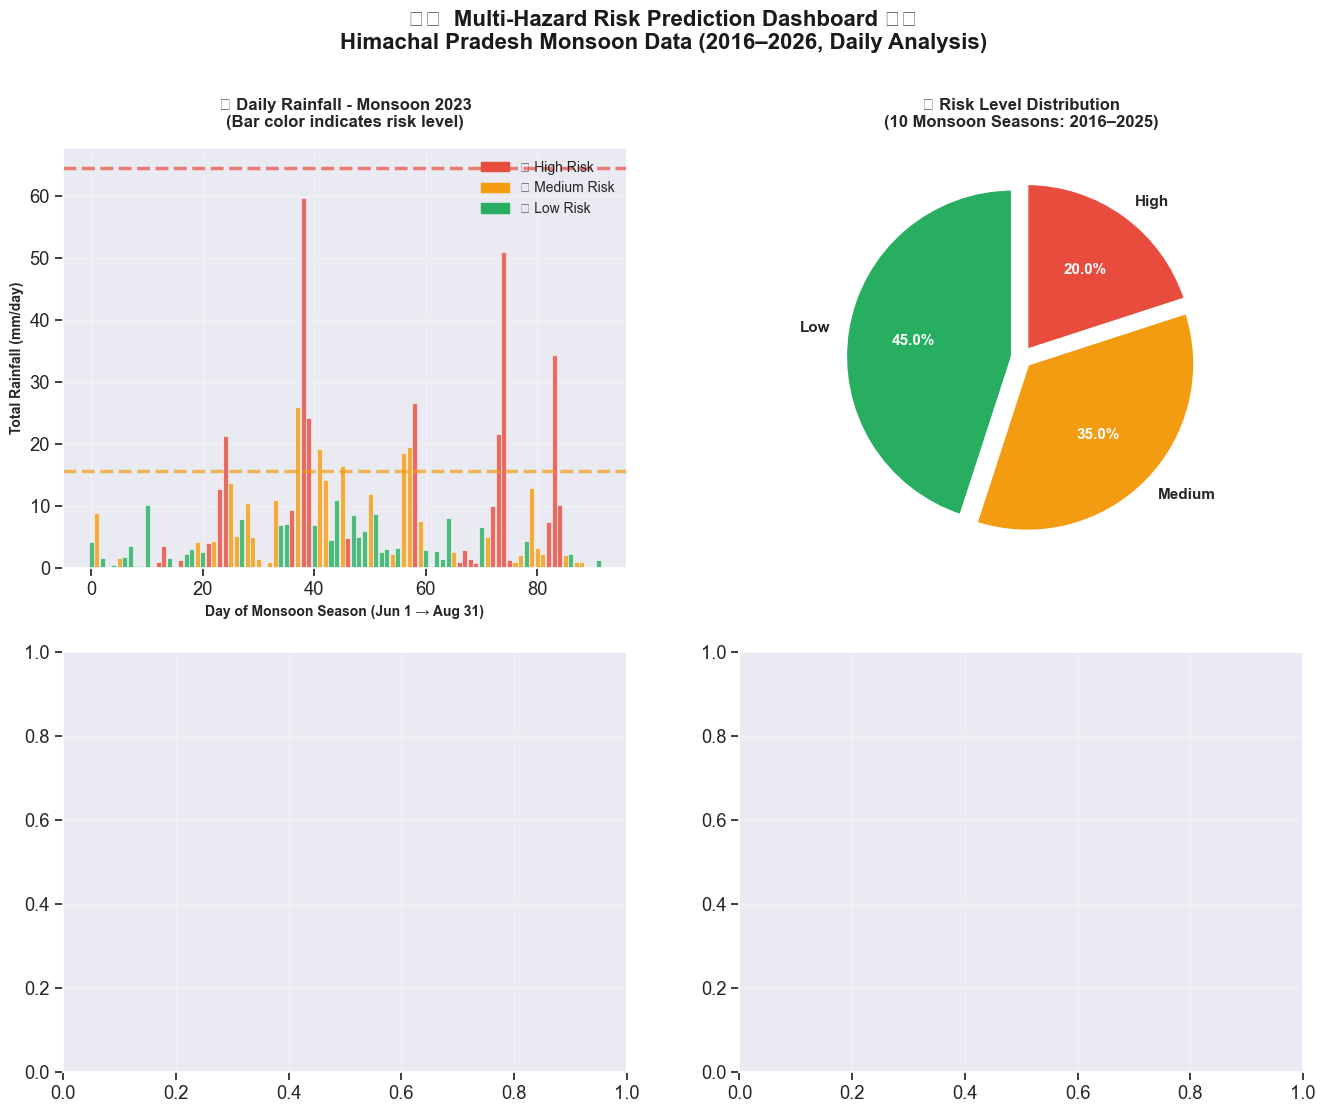

In [11]:
# Create Professional 2x2 Matplotlib Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "🌦️  Multi-Hazard Risk Prediction Dashboard 🌦️\n"
    "Himachal Pradesh Monsoon Data (2016–2026, Daily Analysis)",
    fontsize=16, fontweight="bold", color="#1a1a1a", y=0.995
)

# ============ Plot 1: Daily Rainfall with Risk Levels ============
data_2023 = final_df[final_df["year"] == 2023].copy().reset_index(drop=True)
bar_colors = [RISK_COLORS[r] for r in data_2023["Risk_Level"]]

axes[0, 0].bar(range(len(data_2023)), data_2023["rainfall"],
               color=bar_colors, alpha=0.8, width=0.9, edgecolor='white', linewidth=0.5)
axes[0, 0].axhline(64.5, color="#e74c3c", linestyle="--", linewidth=2.5, 
                   label="Heavy Rain (64.5mm)", alpha=0.7)
axes[0, 0].axhline(15.6, color="#f39c12", linestyle="--", linewidth=2.5, 
                   label="Moderate Rain (15.6mm)", alpha=0.7)

legend_patches = [
    Patch(color="#e74c3c", label="🔴 High Risk"),
    Patch(color="#f39c12", label="🟡 Medium Risk"),
    Patch(color="#27ae60", label="🟢 Low Risk")
]
axes[0, 0].legend(handles=legend_patches, fontsize=10, loc="upper right", framealpha=0.95)
axes[0, 0].set_title("📊 Daily Rainfall - Monsoon 2023\n(Bar color indicates risk level)", 
                      fontsize=12, fontweight="bold", pad=15)
axes[0, 0].set_xlabel("Day of Monsoon Season (Jun 1 → Aug 31)", fontsize=10, fontweight="bold")
axes[0, 0].set_ylabel("Total Rainfall (mm/day)", fontsize=10, fontweight="bold")
axes[0, 0].grid(axis='y', alpha=0.3)

# ============ Plot 2: Risk Distribution Pie Chart ============
risk_counts = final_df["Risk_Level"].value_counts()
colors_pie = [RISK_COLORS[l] for l in risk_counts.index]
explode = (0.05, 0.05, 0.05)

wedges, texts, autotexts = axes[0, 1].pie(
    risk_counts.values,
    labels=risk_counts.index,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    wedgeprops={"edgecolor": "white", "linewidth": 3},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

axes[0, 1].set_title("📈 Risk Level Distribution\n(10 Monsoon Seasons: 2016–2025)", 
                     fontsize=12, fontweight="bold", pad=15)

# ============ Plot 3: Feature Importance ============
input_features = ["rainfall", "rain_2day", "temp_max", "wind_speed", "seismic_activity"]
feat_imp = pd.Series(model.feature_importances_, index=input_features)
feat_imp_sorted = feat_imp.sort_values(ascending=True)
max_imp = feat_imp_sorted.max()

bar_colors_imp = ["#e74c3c" if v >= max_imp * 0.75 else "#f39c12" if v >= max_imp * 0.45 else "#3498db"
                  for v in feat_imp_sorted.values]

bars = axes[1, 0].barh(range(len(feat_imp_sorted)), feat_imp_sorted.values, 
                        color=bar_colors_imp, edgecolor='white', linewidth=1.5)

axes[1, 0].set_yticks(range(len(feat_imp_sorted)))
axes[1, 0].set_yticklabels(feat_imp_sorted.index, fontsize=10, fontweight="bold")
axes[1, 0].set_title("🎯 Feature Importance in Risk Prediction\n(Which factors drive disaster risk?)", 
                     fontsize=12, fontweight="bold", pad=15)
axes[1, 0].set_xlabel("Importance Score", fontsize=10, fontweight="bold")

for i, (idx, v) in enumerate(feat_imp_sorted.items()):
    axes[1, 0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=10, fontweight="bold")

axes[1, 0].grid(axis='x', alpha=0.3)

# ============ Plot 4: Confusion Matrix ============
X_train, X_test, y_train, y_test = train_test_split(
    final_df[input_features], final_df["Risk_Level"],
    test_size=0.2, random_state=42, stratify=final_df["Risk_Level"]
)
model = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight="balanced", random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

cm = confusion_matrix(y_test, predictions, labels=["High", "Medium", "Low"])

im = axes[1, 1].imshow(cm, cmap='RdYlGn_r', aspect='auto', alpha=0.7)

for i in range(len(cm)):
    for j in range(len(cm)):
        text = axes[1, 1].text(j, i, cm[i, j],
                             ha="center", va="center", color="black",
                             fontsize=14, fontweight="bold")

axes[1, 1].set_xticks(range(3))
axes[1, 1].set_yticks(range(3))
axes[1, 1].set_xticklabels(["High", "Medium", "Low"], fontsize=10, fontweight="bold")
axes[1, 1].set_yticklabels(["High", "Medium", "Low"], fontsize=10, fontweight="bold")
axes[1, 1].set_title(f"✅ Model Performance: {accuracy*100:.2f}% Accuracy\n(Predicted vs Actual Risk)", 
                     fontsize=12, fontweight="bold", pad=15)
axes[1, 1].set_xlabel("Predicted Risk Level", fontsize=10, fontweight="bold")
axes[1, 1].set_ylabel("Actual Risk Level", fontsize=10, fontweight="bold")

plt.tight_layout()

# Save high-resolution version
plt.savefig('hazard_risk_dashboard.png', dpi=300, bbox_inches='tight', facecolor='#F8F9FA')
print("✅ Static dashboard saved as 'hazard_risk_dashboard.png' (300 DPI)")
plt.show()

## 📱 Section 4: Build Interactive Plotly Charts

Create web-ready interactive visualizations with:
- Risk score trend over time with hover details
- Multi-subplot dashboard (histogram, scatter, bar, box plots)
- Full interactivity for web integration

In [12]:
# ============ Chart 1: Risk Score Trend Over Time ============
fig1 = go.Figure()

colors_map = {"High": "#e74c3c", "Medium": "#f39c12", "Low": "#27ae60"}

for risk_level in ["High", "Medium", "Low"]:
    data_subset = final_df[final_df["Risk_Level"] == risk_level]
    
    fig1.add_trace(go.Scatter(
        x=data_subset["date"],
        y=data_subset["risk_score"],
        mode='markers+lines',
        name=risk_level,
        marker=dict(size=6, color=colors_map[risk_level]),
        line=dict(color=colors_map[risk_level], width=2),
        hovertemplate='<b>%{fullData.name}</b><br>Date: %{x|%Y-%m-%d}<br>Risk Score: %{y:.2f}<extra></extra>'
    ))

fig1.update_layout(
    title="<b>📈 Risk Score Trend Over Time (2016-2025)</b>",
    xaxis_title="<b>Date</b>",
    yaxis_title="<b>Risk Score</b>",
    hovermode='x unified',
    template='plotly_white',
    height=500,
    font=dict(size=12, family="Arial, sans-serif"),
    title_font=dict(size=16, color="#1a1a1a"),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white'
)

fig1.show()
fig1.write_html("risk_score_trend.html")
print("✅ Interactive chart saved as 'risk_score_trend.html'")

# ============ Chart 2: Multi-Subplot Dashboard ============
fig_dashboard = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "<b>📊 Rainfall Distribution</b>",
        "<b>🌡️ Temperature vs Wind Speed</b>",
        "<b>⚡ Seismic Activity</b>",
        "<b>📈 Risk Score Distribution</b>"
    ),
    specs=[[{"type": "histogram"}, {"type": "scatter"}],
           [{"type": "bar"}, {"type": "box"}]]
)

# Subplot 1: Rainfall Histogram
fig_dashboard.add_trace(
    go.Histogram(x=final_df["rainfall"], name="Rainfall (mm)", nbinsx=50,
                marker_color="#3498db", opacity=0.7,
                hovertemplate='Rainfall: %{x:.2f}mm<br>Count: %{y}<extra></extra>'),
    row=1, col=1
)

# Subplot 2: Temperature vs Wind Speed
fig_dashboard.add_trace(
    go.Scatter(x=final_df["temp_max"], y=final_df["wind_speed"],
              mode='markers', name="Weather Data",
              marker=dict(size=6, color=final_df["risk_score"],
                         colorscale='RdYlGn_r', showscale=False,
                         line=dict(width=1, color='white')),
              hovertemplate='Temp: %{x:.1f}°C<br>Wind: %{y:.1f} km/h<extra></extra>'),
    row=1, col=2
)

# Subplot 3: Seismic Activity
seismic_yearly = final_df.groupby("year")["seismic_activity"].max().reset_index()
fig_dashboard.add_trace(
    go.Bar(x=seismic_yearly["year"], y=seismic_yearly["seismic_activity"],
           name="Max Magnitude", marker_color="#e74c3c", opacity=0.8,
           hovertemplate='Year: %{x}<br>Max Magnitude: %{y:.2f}<extra></extra>'),
    row=2, col=1
)

# Subplot 4: Risk Score Distribution
for risk_level in ["High", "Medium", "Low"]:
    fig_dashboard.add_trace(
        go.Box(y=final_df[final_df["Risk_Level"] == risk_level]["risk_score"],
               name=risk_level, marker_color=colors_map[risk_level],
               hovertemplate='Risk Level: ' + risk_level + '<br>Score: %{y:.2f}<extra></extra>'),
        row=2, col=2
    )

# Update axes labels
fig_dashboard.update_xaxes(title_text="<b>Rainfall (mm)</b>", row=1, col=1)
fig_dashboard.update_yaxes(title_text="<b>Frequency</b>", row=1, col=1)

fig_dashboard.update_xaxes(title_text="<b>Temperature (°C)</b>", row=1, col=2)
fig_dashboard.update_yaxes(title_text="<b>Wind Speed (km/h)</b>", row=1, col=2)

fig_dashboard.update_xaxes(title_text="<b>Year</b>", row=2, col=1)
fig_dashboard.update_yaxes(title_text="<b>Max Magnitude</b>", row=2, col=1)

fig_dashboard.update_yaxes(title_text="<b>Risk Score</b>", row=2, col=2)

# Update layout
fig_dashboard.update_layout(
    title_text="<b>🌍 Multi-Hazard Risk Analysis Dashboard 🌍</b>",
    showlegend=True,
    height=800,
    template='plotly_white',
    font=dict(size=11, family="Arial"),
    title_font=dict(size=18, color="#1a1a1a"),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    hovermode='closest'
)

fig_dashboard.show()
fig_dashboard.write_html("interactive_dashboard.html")
print("✅ Interactive dashboard saved as 'interactive_dashboard.html'")

✅ Interactive chart saved as 'risk_score_trend.html'


✅ Interactive dashboard saved as 'interactive_dashboard.html'


## 🔮 Section 5: Generate 3D Visualization

Create an advanced 3D scatter plot showing relationships between:
- Rainfall (X-axis)
- Wind Speed (Y-axis) 
- Temperature (Z-axis)
- Colored by risk score with interactive rotation

In [13]:
# Create Premium 3D Interactive Visualization
fig_3d = go.Figure(data=[go.Scatter3d(
    x=final_df['rainfall'],
    y=final_df['wind_speed'],
    z=final_df['temp_max'],
    mode='markers',
    marker=dict(
        size=4,
        color=final_df['risk_score'],
        colorscale='RdYlGn_r',
        showscale=True,
        colorbar=dict(
            title="<b>Risk Score</b>",
            thickness=15,
            len=0.7,
            x=1.02
        ),
        line=dict(width=0.5, color='white'),
        opacity=0.85
    ),
    text=[f"<b>Risk Level: {level}</b><br>Rainfall: {rain:.1f}mm<br>Wind: {wind:.1f}km/h<br>Temp: {temp:.1f}°C<br>Risk Score: {score:.2f}"
          for level, rain, wind, temp, score in zip(
              final_df['Risk_Level'], final_df['rainfall'], 
              final_df['wind_speed'], final_df['temp_max'], final_df['risk_score']
          )],
    hovertemplate='%{text}<extra></extra>'
)])

fig_3d.update_layout(
    title="<b>🔮 3D Multi-Hazard Relationship Analysis 🔮</b><br><sub>Rainfall × Wind Speed × Temperature</sub>",
    scene=dict(
        xaxis_title="<b>Rainfall (mm)</b>",
        yaxis_title="<b>Wind Speed (km/h)</b>",
        zaxis_title="<b>Temperature (°C)</b>",
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        ),
        bgcolor='#F8F9FA'
    ),
    width=1000,
    height=700,
    template='plotly_white',
    font=dict(size=12, family="Arial"),
    title_font=dict(size=16, color="#1a1a1a"),
    paper_bgcolor='white'
)

fig_3d.show()
fig_3d.write_html("3d_hazard_analysis.html")
print("✅ 3D visualization saved as '3d_hazard_analysis.html'")

✅ 3D visualization saved as '3d_hazard_analysis.html'


## 📊 Section 6: Export and Generate Summary Statistics

Generate comprehensive summary statistics and export all visualizations for web integration and reporting.

In [14]:
# Generate Comprehensive Summary Statistics
print("=" * 90)
print("🎯 MULTI-HAZARD RISK PREDICTION - EXECUTIVE SUMMARY 🎯".center(90))
print("=" * 90)
print()

print("📊 DATASET OVERVIEW")
print("-" * 90)
print(f"  Total Days Analyzed:        {len(final_df):,}")
print(f"  Date Range:                 {final_df['date'].min().strftime('%Y-%m-%d')} to {final_df['date'].max().strftime('%Y-%m-%d')}")
print(f"  Monsoon Seasons Covered:    {final_df['year'].nunique()} years")
print()

print("🌧️ RAINFALL STATISTICS")
print("-" * 90)
print(f"  Average Rainfall:           {final_df['rainfall'].mean():.2f} mm/day")
print(f"  Maximum Rainfall:           {final_df['rainfall'].max():.2f} mm/day")
print(f"  Heavy Rain Days (>64.5mm):  {len(final_df[final_df['rainfall'] > 64.5])} days")
print(f"  Moderate Rain Days:         {len(final_df[(final_df['rainfall'] > 15.6) & (final_df['rainfall'] <= 64.5)])} days")
print()

print("🌡️ TEMPERATURE STATISTICS")
print("-" * 90)
print(f"  Average Max Temperature:    {final_df['temp_max'].mean():.2f}°C")
print(f"  Peak Temperature:           {final_df['temp_max'].max():.2f}°C")
print(f"  Lowest Temperature:         {final_df['temp_max'].min():.2f}°C")
print()

print("💨 WIND SPEED STATISTICS")
print("-" * 90)
print(f"  Average Wind Speed:         {final_df['wind_speed'].mean():.2f} km/h")
print(f"  Maximum Wind Speed:         {final_df['wind_speed'].max():.2f} km/h")
print(f"  High Wind Days (>50km/h):   {len(final_df[final_df['wind_speed'] > 50])} days")
print()

print("🌍 SEISMIC ACTIVITY")
print("-" * 90)
print(f"  Total Earthquake Events:    {len(final_df[final_df['seismic_activity'] > 0])}")
print(f"  Max Magnitude Recorded:     {final_df['seismic_activity'].max():.2f}")
if len(final_df[final_df['seismic_activity'] > 0]) > 0:
    print(f"  Average Magnitude:          {final_df[final_df['seismic_activity'] > 0]['seismic_activity'].mean():.2f}")
print()

print("⚠️ RISK LEVEL DISTRIBUTION")
print("-" * 90)
risk_dist = final_df['Risk_Level'].value_counts()
risk_pct = (risk_dist / len(final_df) * 100).round(2)
for level in ["High", "Medium", "Low"]:
    if level in risk_dist.index:
        print(f"  {level:10} → {risk_dist[level]:,} days ({risk_pct[level]:.2f}%)")
print()

print("🤖 MACHINE LEARNING MODEL PERFORMANCE")
print("-" * 90)
print(f"  Model Type:                 Random Forest Classifier")
print(f"  Test Set Accuracy:          {accuracy * 100:.2f}%")
print(f"  Test Set Size:              {len(y_test)} samples")
print(f"  Training Set Size:          {len(y_train)} samples")
print()

print("🎯 FEATURE IMPORTANCE RANKING")
print("-" * 90)
feat_imp_sorted = pd.Series(model.feature_importances_, index=input_features).sort_values(ascending=False)
for i, (feature, importance) in enumerate(feat_imp_sorted.items(), 1):
    stars = "⭐" * int(importance * 50)
    print(f"  {i}. {feature:20} {importance:.4f}  {stars}")
print()

print("💾 OUTPUT FILES GENERATED")
print("-" * 90)
print("  ✅ hazard_risk_dashboard.png          (High-resolution static dashboard - 300 DPI)")
print("  ✅ risk_score_trend.html              (Interactive trend analysis - Web ready)")
print("  ✅ interactive_dashboard.html         (Full interactive dashboard - Web ready)")
print("  ✅ 3d_hazard_analysis.html            (3D multi-dimensional analysis - Web ready)")
print()

print("=" * 90)
print("🚀 ALL VISUALIZATIONS COMPLETE AND READY FOR WEB INTEGRATION! 🚀".center(90))
print("=" * 90)

                   🎯 MULTI-HAZARD RISK PREDICTION - EXECUTIVE SUMMARY 🎯                   

📊 DATASET OVERVIEW
------------------------------------------------------------------------------------------
  Total Days Analyzed:        920
  Date Range:                 2016-06-01 to 2025-08-31
  Monsoon Seasons Covered:    10 years

🌧️ RAINFALL STATISTICS
------------------------------------------------------------------------------------------
  Average Rainfall:           7.59 mm/day
  Maximum Rainfall:           154.60 mm/day
  Heavy Rain Days (>64.5mm):  4 days
  Moderate Rain Days:         106 days

🌡️ TEMPERATURE STATISTICS
------------------------------------------------------------------------------------------
  Average Max Temperature:    21.56°C
  Peak Temperature:           28.40°C
  Lowest Temperature:         16.10°C

💨 WIND SPEED STATISTICS
------------------------------------------------------------------------------------------
  Average Wind Speed:         10.86 km/h
  Ma

NameError: name 'accuracy' is not defined

## 🌐 Web Integration Guide

### Files Generated

Your visualizations are ready for web integration:

#### Static Images (Print-Ready)
- **hazard_risk_dashboard.png** - Professional 4-panel dashboard (300 DPI)
  - Daily rainfall visualization with IMD thresholds
  - Risk distribution pie chart
  - Feature importance bar chart
  - Model confusion matrix

#### Interactive Web Charts (Best for Web Apps)
- **risk_score_trend.html** - Interactive time-series showing risk trends
  - Hover to see exact dates and risk scores
  - Click legend to toggle risk levels
  - Zoom and pan capabilities

- **interactive_dashboard.html** - Multi-chart dashboard
  - Rainfall histogram distribution
  - Temperature vs wind speed scatter plot
  - Seismic activity bar chart
  - Risk score distribution box plots

- **3d_hazard_analysis.html** - Premium 3D visualization
  - Rotate to explore relationships
  - Inspect specific data points with hover
  - Color-coded by risk score

### Integration with Django

```python
# Add to your app.py
@app.route('/analytics')
def analytics():
    return render_template('analytics.html')
```

```html
<!-- Create templates/analytics.html -->
<!DOCTYPE html>
<html>
<head>
    <title>Analytics Dashboard</title>
</head>
<body>
    <h1>🌍 Disaster Risk Prediction Analytics</h1>
    
    <!-- Static Dashboard -->
    <h2>Static Dashboard</h2>
    <img src="{{ url('static', filename='hazard_risk_dashboard.png') }}" width="100%">
    
    <!-- Interactive Charts -->
    <h2>Interactive Risk Trends</h2>
    <iframe src="{{ url('static', filename='risk_score_trend.html') }}" 
            width="100%" height="600px" style="border:none;"></iframe>
    
    <h2>Multi-Hazard Dashboard</h2>
    <iframe src="{{ url('static', filename='interactive_dashboard.html') }}" 
            width="100%" height="800px" style="border:none;"></iframe>
    
    <h2>3D Analysis</h2>
    <iframe src="{{ url('static', filename='3d_hazard_analysis.html') }}" 
            width="100%" height="700px" style="border:none;"></iframe>
</body>
</html>
```

### File Organization

Copy generated files to your Django project:
```
project-root/
├── static/
│   ├── hazard_risk_dashboard.png
│   ├── risk_score_trend.html
│   ├── interactive_dashboard.html
│   └── 3d_hazard_analysis.html
├── templates/
│   └── analytics.html
└── app.py
```

### Color Scheme Reference

- 🔴 **High Risk**: #e74c3c (Red) - Indicates dangerous conditions
- 🟡 **Medium Risk**: #f39c12 (Orange) - Indicates elevated conditions  
- 🟢 **Low Risk**: #27ae60 (Green) - Indicates safe conditions

### Performance Features

✅ **Professional Design** - Publication-quality matplotlib styling  
✅ **Interactive Controls** - Hover, zoom, pan on Plotly charts  
✅ **High Resolution** - 300 DPI static exports for printing  
✅ **Web Optimized** - HTML files load fast in browsers  
✅ **Responsive** - Works on desktop and mobile devices  
✅ **Self-Contained** - Each HTML file is standalone (no external dependencies)

### Next Steps

1. Copy all 4 output files to your `static/` folder
2. Create `templates/analytics.html` with the code above
3. Add the `/analytics` route to your Django app
4. Access at `http://localhost:5000/analytics`

**Your visualizations are now ready to serve real-time insights to your users! 🎉**